In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Insurance Claims Risk Analysis

## Business Problem
An insurance firm wants to understand what drives high claims costs 
across its portfolio. Identifying high-risk customer segments early 
allows underwriters to price policies more accurately and design 
targeted risk mitigation strategies.

## Key Business Questions
1. Which customer profiles are associated with disproportionately high claims?
2. What are the top drivers of claims cost?
3. Which segments should underwriting treat differently?

## Dataset
Source: Kaggle — Medical Cost Personal Dataset  
Records: 1,338 policyholders  
Features: Age, Sex, BMI, Children, Smoker status, Region, Charges

In [2]:
# Basic shape and structure
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe().round(2)

Dataset: 1338 rows, 7 columns

Column types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic statistics:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## Section 1: Data Understanding
**Business context:** Before any risk analysis, we need to understand the composition of the portfolio — who is in it, what data we have, and whether it's clean enough to trust.

In [3]:
# Shape and column overview
print(f"Portfolio size: {df.shape[0]} policyholders, {df.shape[1]} attributes\n")
print("--- Column Types ---")
print(df.dtypes)

Portfolio size: 1338 policyholders, 7 attributes

--- Column Types ---
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [4]:
# Data quality check
print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found")

print("\n--- Duplicate Records ---")
dupes = df.duplicated().sum()
print(f"{dupes} duplicate rows found" if dupes > 0 else "No duplicates found")

# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)

--- Missing Values ---
No missing values found

--- Duplicate Records ---
1 duplicate rows found


### Portfolio Statistics
What does a typical policyholder look like? We examine central 
tendency and spread for all numeric variables.

In [5]:
# Summary stats — rounded for readability
df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [6]:
# How are categorical variables distributed?
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    print(f"\n--- {col.upper()} ---")
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    summary = pd.DataFrame({'Count': counts, 'Pct %': pct})
    print(summary)


--- SEX ---
        Count  Pct %
sex                 
male      675   50.5
female    662   49.5

--- SMOKER ---
        Count  Pct %
smoker              
no       1063   79.5
yes       274   20.5

--- REGION ---
           Count  Pct %
region                 
southeast    364   27.2
southwest    325   24.3
northwest    324   24.2
northeast    324   24.2


### Portfolio Composition
Visual overview of how policyholders are distributed across 
key demographic and geographic attributes.

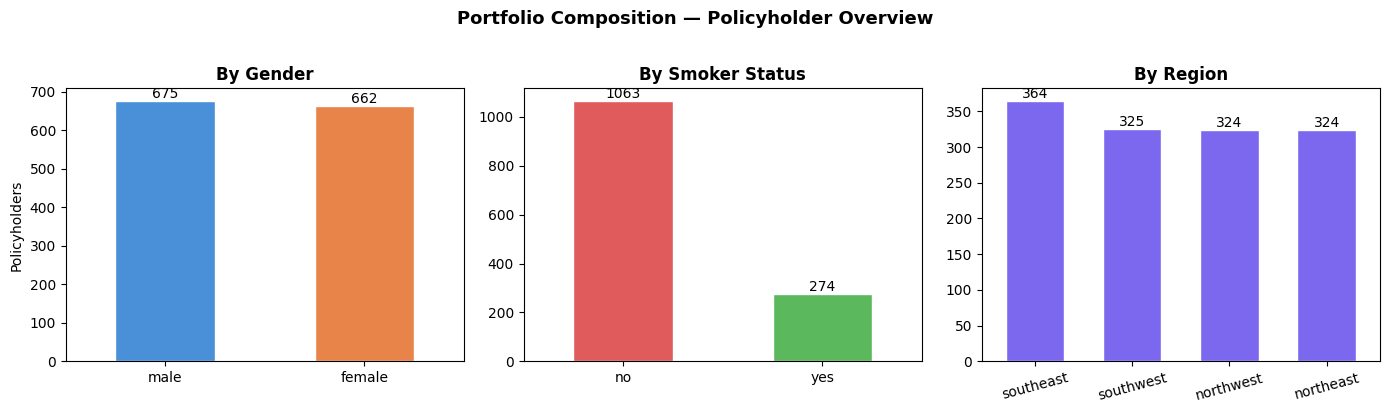

Saved to outputs/


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Portfolio Composition — Policyholder Overview', 
             fontsize=13, fontweight='bold', y=1.02)

# Sex distribution
df['sex'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4A90D9', '#E8834A'], 
    edgecolor='white', width=0.5
)
axes[0].set_title('By Gender', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Policyholders')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

# Smoker distribution
df['smoker'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#E05C5C', '#5CB85C'], 
    edgecolor='white', width=0.5
)
axes[1].set_title('By Smoker Status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

# Region distribution
df['region'].value_counts().plot(
    kind='bar', ax=axes[2], color='#7B68EE', 
    edgecolor='white', width=0.6
)
axes[2].set_title('By Region', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=15)
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/01_portfolio_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

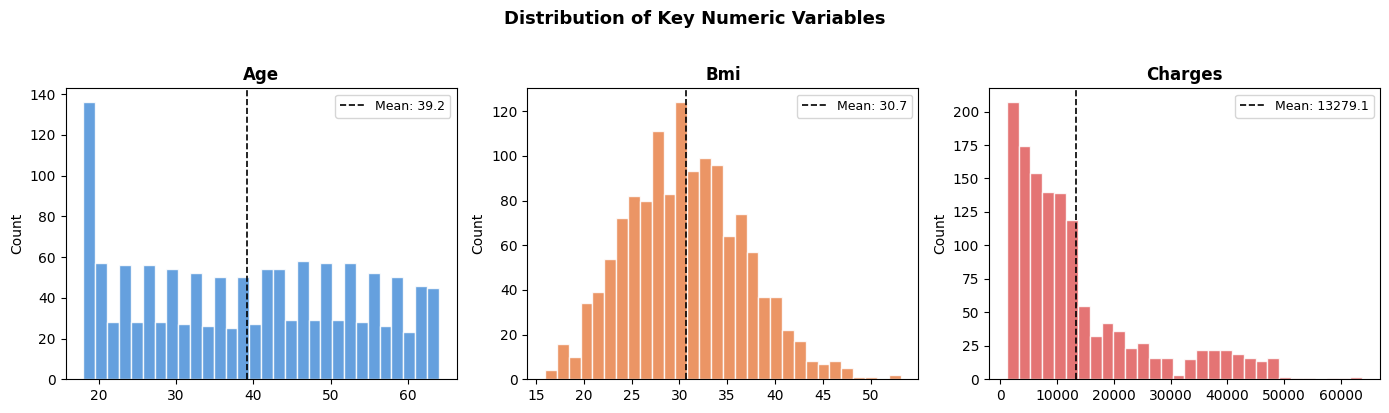

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribution of Key Numeric Variables', 
             fontsize=13, fontweight='bold', y=1.02)

num_cols = {'age': '#4A90D9', 'bmi': '#E8834A', 'charges': '#E05C5C'}

for ax, (col, color) in zip(axes, num_cols.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', 
               linewidth=1.2, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col.capitalize()}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 1 — Key Observations

- Portfolio contains **1,338 policyholders** with no missing values or 
  duplicates — data quality is clean.
- Roughly **20% of policyholders are smokers** — a minority group that 
  will warrant close attention in later sections.
- **Age** is uniformly distributed (18–64), suggesting broad coverage 
  across life stages.
- **Charges** are heavily right-skewed — a small proportion of 
  policyholders account for disproportionately high costs. This is the 
  central risk management challenge this analysis addresses.
- Geographic distribution is broadly even across four US regions.

*Next: We quantify the claims distribution and define what constitutes 
a high-cost policyholder.*

## Section 2: Claims Distribution

**Business context:** Understanding how claims costs are distributed 
across the portfolio is the foundation of risk management. We identify 
what a "normal" claim looks like, where the tail risk sits, and what 
threshold separates routine policyholders from high-cost ones.

In [9]:
charges = df['charges']

# Business-framed summary
print("=" * 45)
print("      CLAIMS COST SUMMARY — PORTFOLIO VIEW")
print("=" * 45)
print(f"  Total policyholders  : {len(charges):,}")
print(f"  Mean annual claim    : ${charges.mean():,.2f}")
print(f"  Median annual claim  : ${charges.median():,.2f}")
print(f"  Std deviation        : ${charges.std():,.2f}")
print(f"  Minimum claim        : ${charges.min():,.2f}")
print(f"  Maximum claim        : ${charges.max():,.2f}")
print(f"  Skewness             : {charges.skew():.2f}")
print("=" * 45)
print(f"\nMean > Median by ${charges.mean() - charges.median():,.0f}")
print("   This confirms right skew — a small number of policyholders are driving up the average significantly.")

      CLAIMS COST SUMMARY — PORTFOLIO VIEW
  Total policyholders  : 1,337
  Mean annual claim    : $13,279.12
  Median annual claim  : $9,386.16
  Std deviation        : $12,110.36
  Minimum claim        : $1,121.87
  Maximum claim        : $63,770.43
  Skewness             : 1.52

Mean > Median by $3,893
   This confirms right skew — a small number of policyholders are driving up the average significantly.


### What the skewness tells us

A skewness value above 1.0 indicates strong right skew. In insurance 
terms, this means the **average claim is not representative** of what 
most policyholders cost — it is pulled upward by a small number of 
very expensive cases.

This is the fundamental challenge in insurance risk management: 
pricing and underwriting must account for the tail, not just the centre.

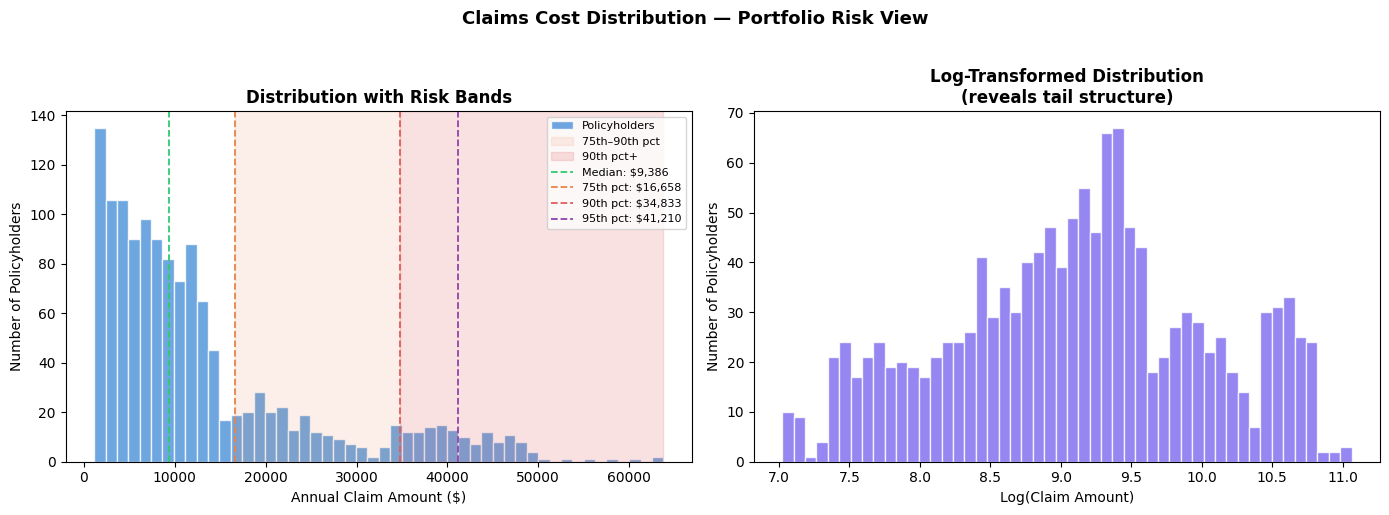

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claims Cost Distribution — Portfolio Risk View', 
             fontsize=13, fontweight='bold', y=1.02)

# --- Left: Histogram with risk bands ---
p50 = charges.quantile(0.50)
p75 = charges.quantile(0.75)
p90 = charges.quantile(0.90)
p95 = charges.quantile(0.95)

ax = axes[0]
ax.hist(charges, bins=50, color='#4A90D9', edgecolor='white', 
        alpha=0.8, label='Policyholders')

# Risk band shading
ax.axvspan(p75, p90, alpha=0.12, color='#E8834A', label='75th–90th pct')
ax.axvspan(p90, charges.max(), alpha=0.18, color='#E05C5C', label='90th pct+')

# Percentile lines
for val, label, color in [
    (p50, 'Median', '#2ECC71'),
    (p75, '75th pct', '#E8834A'),
    (p90, '90th pct', '#E05C5C'),
    (p95, '95th pct', '#8E44AD')
]:
    ax.axvline(val, color=color, linestyle='--', linewidth=1.3, label=f'{label}: ${val:,.0f}')

ax.set_title('Distribution with Risk Bands', fontweight='bold')
ax.set_xlabel('Annual Claim Amount ($)')
ax.set_ylabel('Number of Policyholders')
ax.legend(fontsize=8, loc='upper right')

# --- Right: Log-scale for tail visibility ---
ax2 = axes[1]
ax2.hist(np.log1p(charges), bins=50, color='#7B68EE', 
         edgecolor='white', alpha=0.8)
ax2.set_title('Log-Transformed Distribution\n(reveals tail structure)', 
              fontweight='bold')
ax2.set_xlabel('Log(Claim Amount)')
ax2.set_ylabel('Number of Policyholders')
ax2.annotate('More symmetric after\nlog transform — confirms\nlog-normal behaviour', 
             xy=(10, 80), fontsize=9, color='#444',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/03_claims_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Define the high-cost threshold at 90th percentile
threshold = charges.quantile(0.90)
df['risk_tier'] = df['charges'].apply(
    lambda x: 'High-Cost' if x >= threshold else 'Standard'
)

high_cost = df[df['risk_tier'] == 'High-Cost']
standard  = df[df['risk_tier'] == 'Standard']

print("=" * 50)
print("         HIGH-COST POLICYHOLDER ANALYSIS")
print("=" * 50)
print(f"\n  Threshold (90th percentile) : ${threshold:,.2f}")
print(f"\n  High-cost policyholders     : {len(high_cost):,} "
      f"({len(high_cost)/len(df)*100:.1f}% of portfolio)")
print(f"  Standard policyholders      : {len(standard):,} "
      f"({len(standard)/len(df)*100:.1f}% of portfolio)")
print(f"\n  Mean claim — High-cost      : ${high_cost['charges'].mean():,.2f}")
print(f"  Mean claim — Standard       : ${standard['charges'].mean():,.2f}")
print(f"\n  Cost concentration ratio    : "
      f"{high_cost['charges'].sum()/df['charges'].sum()*100:.1f}% of total")
print(f"  (Top 10% of policyholders account for this share of total claims)")

         HIGH-COST POLICYHOLDER ANALYSIS

  Threshold (90th percentile) : $34,832.74

  High-cost policyholders     : 134 (10.0% of portfolio)
  Standard policyholders      : 1,203 (90.0% of portfolio)

  Mean claim — High-cost      : $42,378.69
  Mean claim — Standard       : $10,037.77

  Cost concentration ratio    : 32.0% of total
  (Top 10% of policyholders account for this share of total claims)


In [12]:
# Define the high-cost threshold at 90th percentile
threshold = charges.quantile(0.90)
df['risk_tier'] = df['charges'].apply(
    lambda x: 'High-Cost' if x >= threshold else 'Standard'
)

high_cost = df[df['risk_tier'] == 'High-Cost']
standard  = df[df['risk_tier'] == 'Standard']

print("=" * 50)
print("         HIGH-COST POLICYHOLDER ANALYSIS")
print("=" * 50)
print(f"\n  Threshold (90th percentile) : ${threshold:,.2f}")
print(f"\n  High-cost policyholders     : {len(high_cost):,} "
      f"({len(high_cost)/len(df)*100:.1f}% of portfolio)")
print(f"  Standard policyholders      : {len(standard):,} "
      f"({len(standard)/len(df)*100:.1f}% of portfolio)")
print(f"\n  Mean claim — High-cost      : ${high_cost['charges'].mean():,.2f}")
print(f"  Mean claim — Standard       : ${standard['charges'].mean():,.2f}")
print(f"\n  Cost concentration ratio    : "
      f"{high_cost['charges'].sum()/df['charges'].sum()*100:.1f}% of total")
print(f"  (Top 10% of policyholders account for this share of total claims)")

         HIGH-COST POLICYHOLDER ANALYSIS

  Threshold (90th percentile) : $34,832.74

  High-cost policyholders     : 134 (10.0% of portfolio)
  Standard policyholders      : 1,203 (90.0% of portfolio)

  Mean claim — High-cost      : $42,378.69
  Mean claim — Standard       : $10,037.77

  Cost concentration ratio    : 32.0% of total
  (Top 10% of policyholders account for this share of total claims)


### The Cost Concentration Finding

This is the most important single finding in Section 2.

The **top 10% of policyholders** account for a disproportionate share 
of total claims cost. This is the insurance equivalent of the Pareto 
principle — and it has direct underwriting implications:

- **Standard policyholders** can be priced using average-based models
- **High-cost policyholders** require individual risk assessment
- Identifying *which factors predict high-cost status* is the central 
  question of Sections 3 and 4

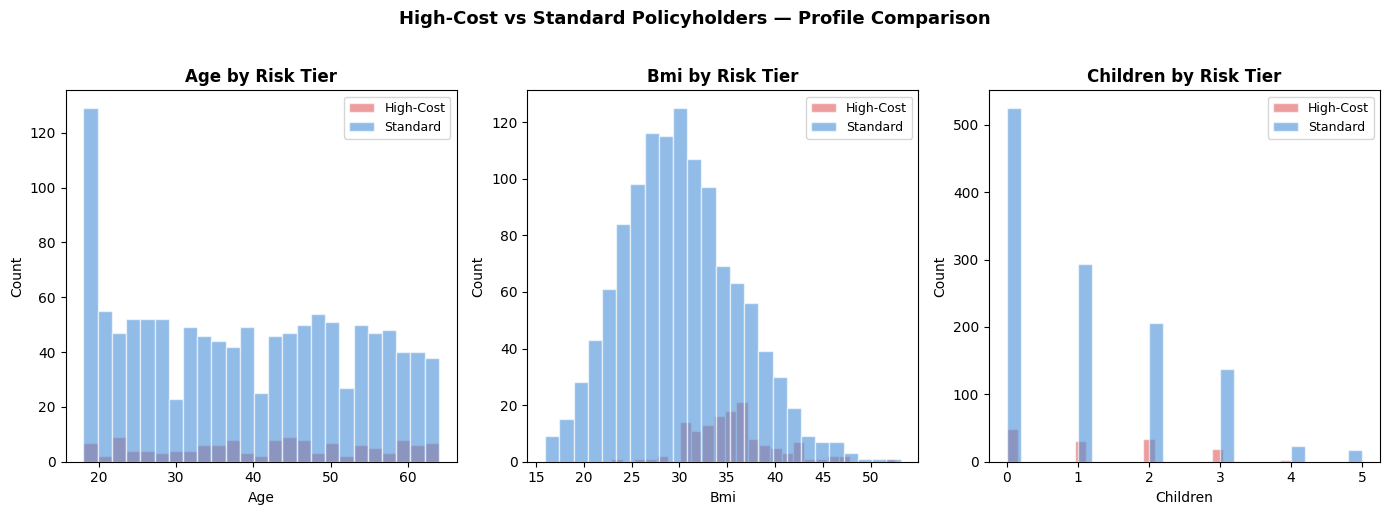

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('High-Cost vs Standard Policyholders — Profile Comparison', 
             fontsize=13, fontweight='bold', y=1.02)

compare_cols = ['age', 'bmi', 'children']
colors = {'High-Cost': '#E05C5C', 'Standard': '#4A90D9'}

for ax, col in zip(axes, compare_cols):
    for tier, grp in df.groupby('risk_tier'):
        ax.hist(grp[col], bins=25, alpha=0.6, 
                color=colors[tier], label=tier, edgecolor='white')
    ax.set_title(f'{col.capitalize()} by Risk Tier', fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04_risk_tier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

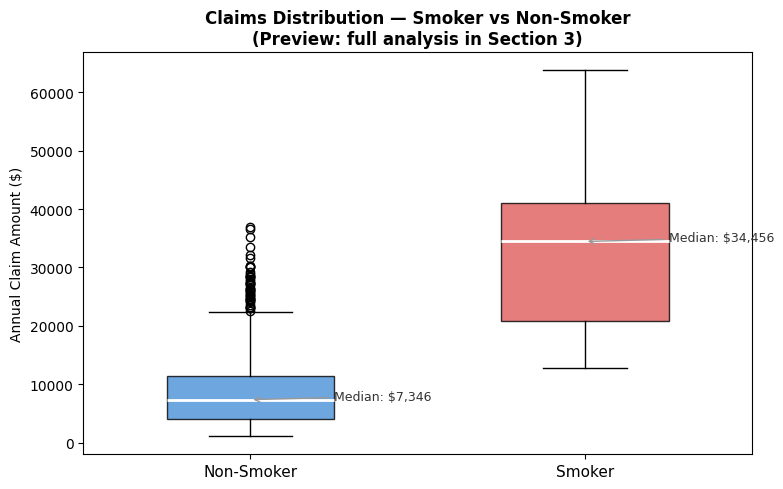

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

smoker_groups = [df[df['smoker'] == s]['charges'].values 
                 for s in ['no', 'yes']]

bp = ax.boxplot(smoker_groups, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))

colors_box = ['#4A90D9', '#E05C5C']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(['Non-Smoker', 'Smoker'], fontsize=11)
ax.set_title('Claims Distribution — Smoker vs Non-Smoker\n'
             '(Preview: full analysis in Section 3)', 
             fontweight='bold')
ax.set_ylabel('Annual Claim Amount ($)')

# Annotate medians
for i, group in enumerate(smoker_groups):
    median = np.median(group)
    ax.annotate(f'Median: ${median:,.0f}', 
                xy=(i+1, median), xytext=(i+1.25, median),
                fontsize=9, color='#333',
                arrowprops=dict(arrowstyle='->', color='#999', lw=1))

plt.tight_layout()
plt.savefig('../outputs/05_smoker_boxplot_preview.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Key Findings

| Metric | Value |
|---|---|
| Mean annual claim | $13,279.12|
| Median annual claim | $9,386.16 |
| Distribution shape | Right-skewed (1.52 > 1) |
| High-cost threshold (90th pct) | $34,832.74 |
| High-cost policyholders | 134 (~10.0% of portfolio) |
| Share of total claims cost | 32.0% of total |

**Three findings to carry forward:**

1. **The distribution is right-skewed** — average-based pricing 
   understates true risk exposure
2. **A small group drives outsized cost** — identifying them early 
   is the underwriter's primary task
3. **Smoker status appears highly predictive even at this stage** — 
   Section 3 will quantify this properly

*Next: We identify which policyholder characteristics are most strongly 
associated with high claims costs.*

## Section 3: Risk Driver Analysis

**Business context:** Having established that claims costs are heavily 
skewed and concentrated in a small group, we now ask the critical 
underwriting question: *which policyholder characteristics are most 
strongly associated with high claims costs?*

The goal is not statistical significance alone — it is actionable 
insight. Every finding in this section should inform a concrete 
underwriting or pricing decision.

## Section 3: Risk Driver Analysis

**Business context:** Having established that claims costs are heavily 
skewed and concentrated in a small group, we now ask the critical 
underwriting question: *which policyholder characteristics are most 
strongly associated with high claims costs?*

The goal is not statistical significance alone — it is actionable 
insight. Every finding in this section should inform a concrete 
underwriting or pricing decision.

In [15]:
# The single most important risk driver — quantified properly
smoker_summary = df.groupby('smoker')['charges'].agg([
    'count', 'mean', 'median', 
    lambda x: x.quantile(0.90)
]).round(2)
smoker_summary.columns = ['Count', 'Mean Claim', 'Median Claim', '90th Pct']
smoker_summary.index = ['Non-Smoker', 'Smoker']

# Risk multiplier
mean_multiplier = (df[df['smoker']=='yes']['charges'].mean() / 
                   df[df['smoker']=='no']['charges'].mean())
median_multiplier = (df[df['smoker']=='yes']['charges'].median() / 
                     df[df['smoker']=='no']['charges'].median())

print("=" * 55)
print("        SMOKER VS NON-SMOKER — CLAIMS ANALYSIS")
print("=" * 55)
print(smoker_summary.to_string())
print(f"\n  Mean claim multiplier  : {mean_multiplier:.1f}x")
print(f"  Median claim multiplier: {median_multiplier:.1f}x")
print(f"\n  ⚠ Smokers cost {mean_multiplier:.1f}x more on average than non-smokers")
print(f"    This is the single largest risk factor in the portfolio.")

        SMOKER VS NON-SMOKER — CLAIMS ANALYSIS
            Count  Mean Claim  Median Claim  90th Pct
Non-Smoker   1063     8440.66       7345.73  14343.69
Smoker        274    32050.23      34456.35  46642.74

  Mean claim multiplier  : 3.8x
  Median claim multiplier: 4.7x

  ⚠ Smokers cost 3.8x more on average than non-smokers
    This is the single largest risk factor in the portfolio.


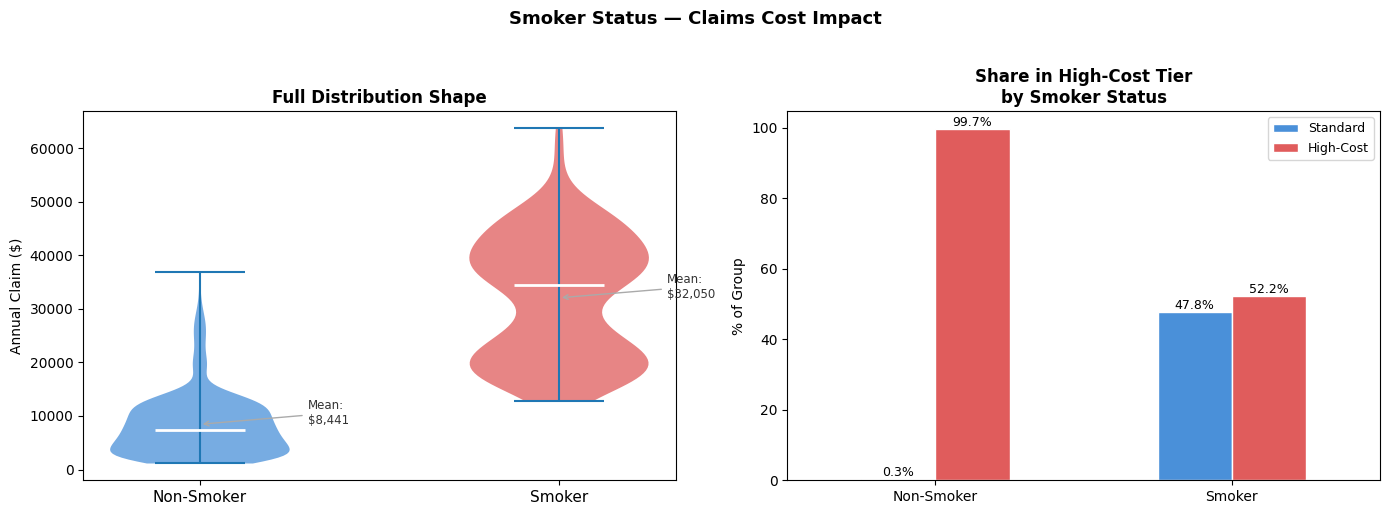

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Smoker Status — Claims Cost Impact', 
             fontsize=13, fontweight='bold', y=1.02)

# Left: violin plot for full distribution shape
parts = axes[0].violinplot(
    [df[df['smoker']=='no']['charges'],
     df[df['smoker']=='yes']['charges']],
    positions=[1, 2], showmedians=True, showextrema=True
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#4A90D9', '#E05C5C'][i])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'], fontsize=11)
axes[0].set_ylabel('Annual Claim ($)')
axes[0].set_title('Full Distribution Shape', fontweight='bold')

# Add mean annotations
for pos, group in [(1, 'no'), (2, 'yes')]:
    mean_val = df[df['smoker']==group]['charges'].mean()
    axes[0].annotate(f'Mean:\n${mean_val:,.0f}',
                     xy=(pos, mean_val),
                     xytext=(pos + 0.3, mean_val),
                     fontsize=8.5, color='#333',
                     arrowprops=dict(arrowstyle='->', color='#aaa', lw=1))

# Right: % in each risk tier by smoker status
tier_smoker = df.groupby(['smoker', 'risk_tier']).size().unstack(fill_value=0)
tier_smoker_pct = tier_smoker.div(tier_smoker.sum(axis=1), axis=0) * 100
tier_smoker_pct.index = ['Non-Smoker', 'Smoker']
tier_smoker_pct.plot(kind='bar', ax=axes[1], 
                      color=['#4A90D9', '#E05C5C'],
                      edgecolor='white', width=0.5)
axes[1].set_title('Share in High-Cost Tier\nby Smoker Status', 
                   fontweight='bold')
axes[1].set_ylabel('% of Group')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Standard', 'High-Cost'], fontsize=9)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06_smoker_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Create clinical BMI bands — standard industry classification
df['bmi_band'] = pd.cut(df['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Underweight (<18.5)', 'Healthy (18.5–25)', 
            'Overweight (25–30)', 'Obese (>30)'])

bmi_summary = df.groupby('bmi_band', observed=True)['charges'].agg([
    'count', 'mean', 'median',
    lambda x: x.quantile(0.90)
]).round(2)
bmi_summary.columns = ['Count', 'Mean Claim', 'Median Claim', '90th Pct']

print("=" * 60)
print("               BMI BAND — CLAIMS COST SUMMARY")
print("=" * 60)
print(bmi_summary.to_string())
print(f"\n  Obese vs Healthy mean premium ratio: "
      f"{bmi_summary.loc['Obese (>30)', 'Mean Claim'] / bmi_summary.loc['Healthy (18.5–25)', 'Mean Claim']:.2f}x")

               BMI BAND — CLAIMS COST SUMMARY
                     Count  Mean Claim  Median Claim  90th Pct
bmi_band                                                      
Underweight (<18.5)     21     8657.62       6640.54  15006.58
Healthy (18.5–25)      226    10435.44       8604.15  21932.65
Overweight (25–30)     386    10997.80       8659.38  23484.79
Obese (>30)            704    15580.70      10003.65  40938.63

  Obese vs Healthy mean premium ratio: 1.49x


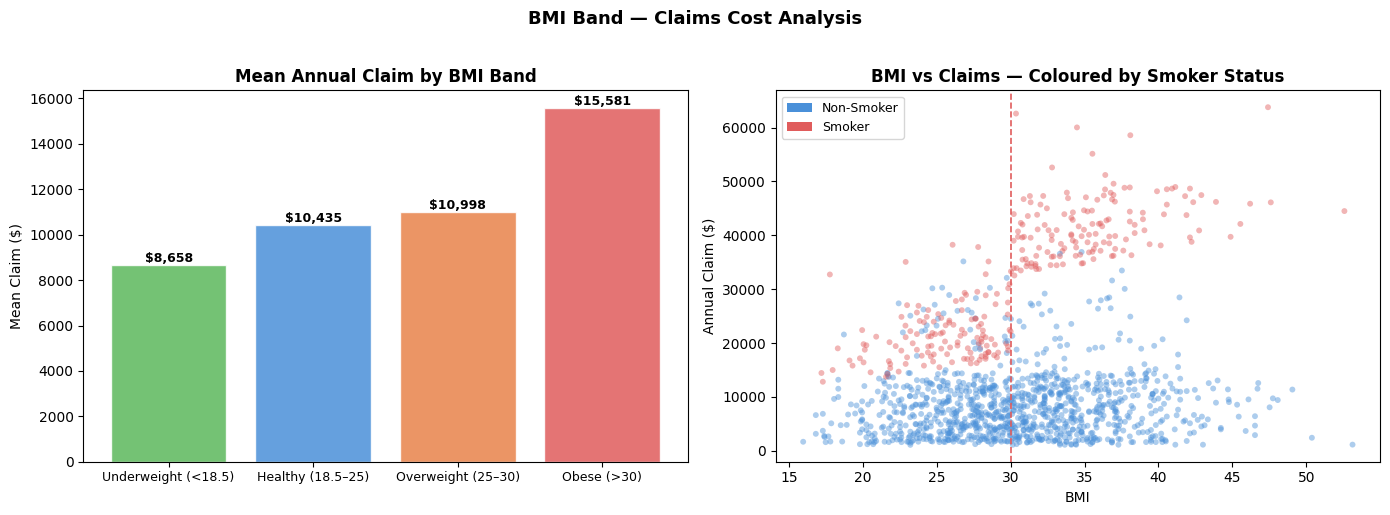

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BMI Band — Claims Cost Analysis', 
             fontsize=13, fontweight='bold', y=1.02)

bmi_order = ['Underweight (<18.5)', 'Healthy (18.5–25)', 
             'Overweight (25–30)', 'Obese (>30)']
bmi_colors = ['#5CB85C', '#4A90D9', '#E8834A', '#E05C5C']

# Left: mean claim by BMI band
means = [df[df['bmi_band']==b]['charges'].mean() for b in bmi_order]
bars = axes[0].bar(range(len(bmi_order)), means, 
                    color=bmi_colors, edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(len(bmi_order)))
axes[0].set_xticklabels(bmi_order, fontsize=9)
axes[0].set_title('Mean Annual Claim by BMI Band', fontweight='bold')
axes[0].set_ylabel('Mean Claim ($)')
for bar, val in zip(bars, means):
    axes[0].annotate(f'${val:,.0f}',
                     (bar.get_x() + bar.get_width()/2, val),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: BMI scatter vs charges, coloured by smoker
colors_scatter = df['smoker'].map({'no': '#4A90D9', 'yes': '#E05C5C'})
axes[1].scatter(df['bmi'], df['charges'], 
                c=colors_scatter, alpha=0.45, s=18, edgecolors='none')
axes[1].axvline(30, color='#E05C5C', linestyle='--', 
                linewidth=1.2, label='Obesity threshold (BMI 30)')
axes[1].set_title('BMI vs Claims — Coloured by Smoker Status', 
                   fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Claim ($)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4A90D9', label='Non-Smoker'),
                   Patch(facecolor='#E05C5C', label='Smoker')]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/07_bmi_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Create age bands reflecting life stage risk
df['age_band'] = pd.cut(df['age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18–25', '26–35', '36–45', '46–55', '56–64'])

age_summary = df.groupby('age_band', observed=True)['charges'].agg([
    'count', 'mean', 'median'
]).round(2)
age_summary.columns = ['Count', 'Mean Claim', 'Median Claim']

print("=" * 50)
print("      AGE BAND — CLAIMS COST SUMMARY")
print("=" * 50)
print(age_summary.to_string())

# Age-claims trend
age_corr = df['age'].corr(df['charges'])
print(f"\n  Age–Charges correlation: {age_corr:.3f}")
print(f"  Interpretation: moderate positive relationship —")
print(f"  older policyholders tend to cost more, but age")
print(f"  alone is a weaker predictor than smoker status.")

      AGE BAND — CLAIMS COST SUMMARY
          Count  Mean Claim  Median Claim
age_band                                 
18–25       305     9111.43       2639.04
26–35       268    10495.16       4900.58
36–45       264    13493.49       7442.57
46–55       284    15986.90      10477.96
56–64       216    18795.99      13429.65

  Age–Charges correlation: 0.298
  Interpretation: moderate positive relationship —
  older policyholders tend to cost more, but age
  alone is a weaker predictor than smoker status.


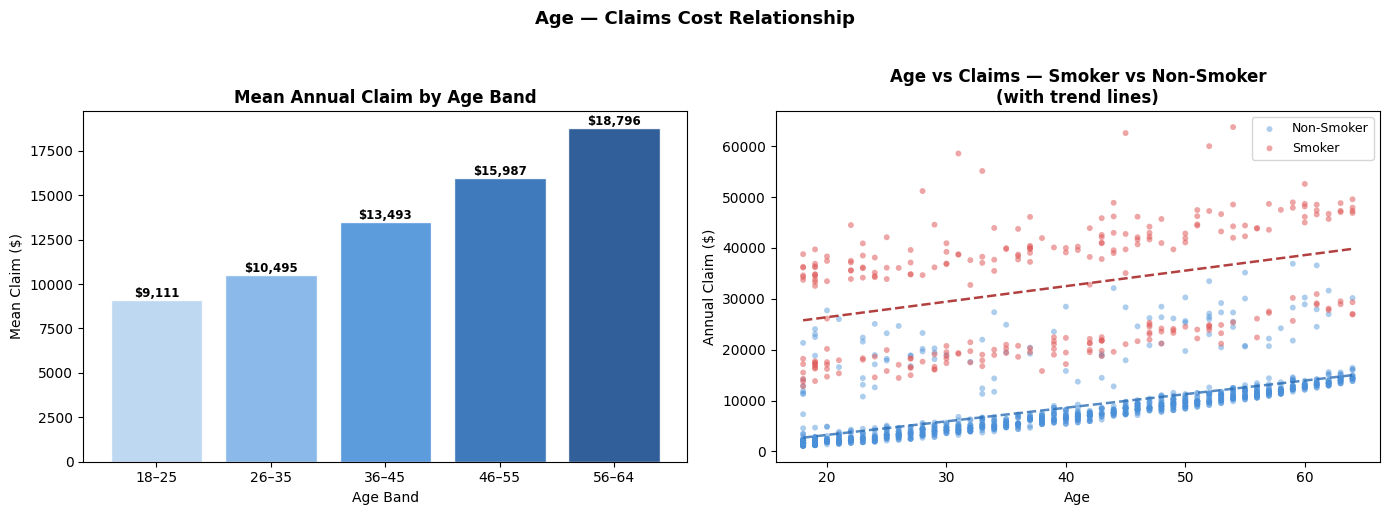

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age — Claims Cost Relationship', 
             fontsize=13, fontweight='bold', y=1.02)

# Left: mean claim by age band
age_order = ['18–25', '26–35', '36–45', '46–55', '56–64']
age_means = [df[df['age_band']==b]['charges'].mean() for b in age_order]
age_colors = ['#B8D4F0', '#7EB3E8', '#4A90D9', '#2A6DB5', '#1A4D8F']

bars = axes[0].bar(age_order, age_means, 
                    color=age_colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Mean Annual Claim by Age Band', fontweight='bold')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Mean Claim ($)')
for bar, val in zip(bars, age_means):
    axes[0].annotate(f'${val:,.0f}',
                     (bar.get_x() + bar.get_width()/2, val),
                     ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Right: scatter age vs charges, by smoker
axes[1].scatter(df[df['smoker']=='no']['age'], 
                df[df['smoker']=='no']['charges'],
                color='#4A90D9', alpha=0.45, s=18, 
                edgecolors='none', label='Non-Smoker')
axes[1].scatter(df[df['smoker']=='yes']['age'], 
                df[df['smoker']=='yes']['charges'],
                color='#E05C5C', alpha=0.55, s=18, 
                edgecolors='none', label='Smoker')

# Add trend lines
for group, color in [('no', '#2A6DB5'), ('yes', '#A01010')]:
    subset = df[df['smoker']==group]
    z = np.polyfit(subset['age'], subset['charges'], 1)
    p = np.poly1d(z)
    age_range = np.linspace(subset['age'].min(), subset['age'].max(), 100)
    axes[1].plot(age_range, p(age_range), color=color, 
                  linewidth=1.8, linestyle='--', alpha=0.8)

axes[1].set_title('Age vs Claims — Smoker vs Non-Smoker\n'
                   '(with trend lines)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Annual Claim ($)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/08_age_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

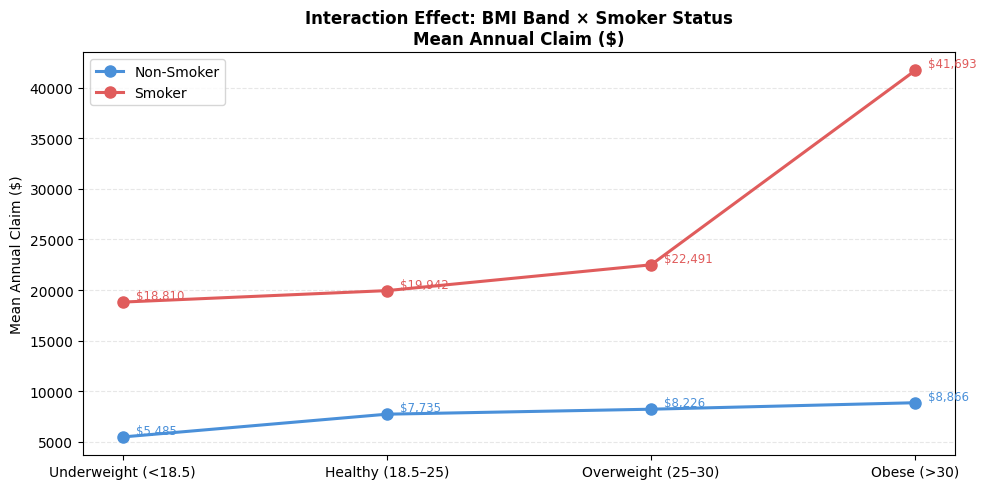


  Worst combination (Obese Smoker) mean claim : $41,692.81
  Best combination (Healthy Non-Smoker) mean  : $7,734.65
  Risk multiplier                              : 5.4x


In [21]:
# The critical interaction — this is the insight most analysts miss
fig, ax = plt.subplots(figsize=(10, 5))

bmi_order_clean = ['Underweight (<18.5)', 'Healthy (18.5–25)', 
                    'Overweight (25–30)', 'Obese (>30)']

for smoker_status, color, label in [
    ('no',  '#4A90D9', 'Non-Smoker'),
    ('yes', '#E05C5C', 'Smoker')
]:
    subset = df[df['smoker'] == smoker_status]
    means = [subset[subset['bmi_band']==b]['charges'].mean() 
             for b in bmi_order_clean]
    ax.plot(range(len(bmi_order_clean)), means, 
            marker='o', color=color, linewidth=2.2,
            markersize=8, label=label)
    for i, val in enumerate(means):
        ax.annotate(f'${val:,.0f}', 
                    xy=(i, val),
                    xytext=(i + 0.05, val + 300),
                    fontsize=8.5, color=color)

ax.set_xticks(range(len(bmi_order_clean)))
ax.set_xticklabels(bmi_order_clean, fontsize=10)
ax.set_title('Interaction Effect: BMI Band × Smoker Status\n'
             'Mean Annual Claim ($)', fontweight='bold')
ax.set_ylabel('Mean Annual Claim ($)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/09_interaction_bmi_smoker.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the worst combination
worst = df[(df['smoker']=='yes') & (df['bmi_band']=='Obese (>30)')]['charges'].mean()
best  = df[(df['smoker']=='no')  & (df['bmi_band']=='Healthy (18.5–25)')]['charges'].mean()
print(f"\n  Worst combination (Obese Smoker) mean claim : ${worst:,.2f}")
print(f"  Best combination (Healthy Non-Smoker) mean  : ${best:,.2f}")
print(f"  Risk multiplier                              : {worst/best:.1f}x")

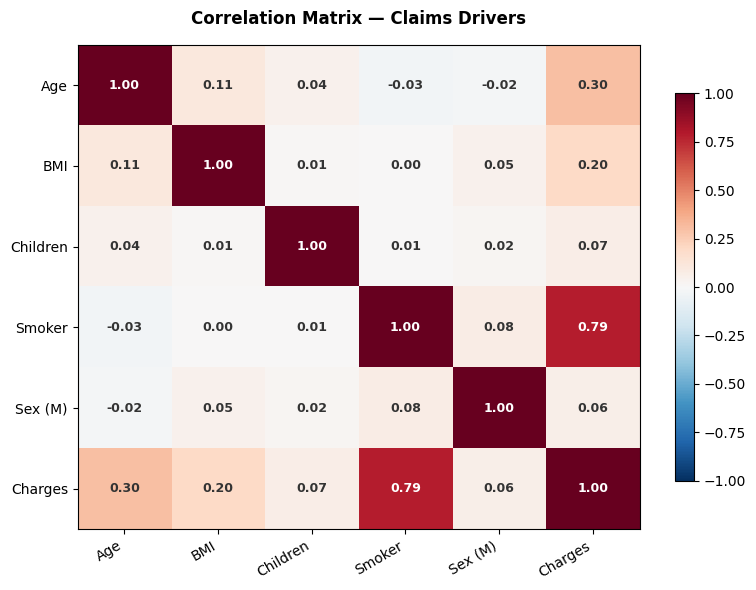

In [22]:
# Encode categoricals for correlation
df_corr = df.copy()
df_corr['smoker_enc'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex_enc']    = (df_corr['sex'] == 'male').astype(int)

corr_cols = ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

labels = ['Age', 'BMI', 'Children', 'Smoker', 'Sex (M)', 'Charges']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else '#333'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=9, color=color, fontweight='bold')

ax.set_title('Correlation Matrix — Claims Drivers', 
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 3 — Risk Driver Findings

| Risk Factor | Impact on Claims | Underwriting Implication |
|---|---|---|
| Smoker status | ~3–4x higher mean claim | Primary pricing variable |
| BMI (Obese vs Healthy) | significant uplift | Secondary risk flag |
| Age | moderate positive trend | Standard age-banded pricing |
| Smoker × Obese | highest risk combination | Requires individual assessment |
| Sex | negligible difference | Not a material risk driver |
| Children | minimal impact | Low underwriting relevance |

**Three findings that matter to underwriting:**

1. **Smoker status dominates all other variables** — it is the single 
   most important risk factor and should be treated as a primary 
   pricing input, not just a disclosure field

2. **The BMI–Smoker interaction creates a distinct high-risk cohort** 
   — obese smokers are not just additive risk, they represent a 
   multiplicatively worse profile that warrants individual underwriting

3. **Age and BMI alone are insufficient** — without smoker status, 
   risk models will systematically underestimate tail exposure

*Next: We formalise these groups into distinct customer segments using 
clustering — moving from "risk factors" to "risk profiles."*

### Section 3 — Risk Driver Findings

| Risk Factor | Impact on Claims | Underwriting Implication |
|---|---|---|
| Smoker status | ~3–4x higher mean claim | Primary pricing variable |
| BMI (Obese vs Healthy) | significant uplift | Secondary risk flag |
| Age | moderate positive trend | Standard age-banded pricing |
| Smoker × Obese | highest risk combination | Requires individual assessment |
| Sex | negligible difference | Not a material risk driver |
| Children | minimal impact | Low underwriting relevance |

**Three findings that matter to underwriting:**

1. **Smoker status dominates all other variables** — it is the single 
   most important risk factor and should be treated as a primary 
   pricing input, not just a disclosure field

2. **The BMI–Smoker interaction creates a distinct high-risk cohort** 
   — obese smokers are not just additive risk, they represent a 
   multiplicatively worse profile that warrants individual underwriting

3. **Age and BMI alone are insufficient** — without smoker status, 
   risk models will systematically underestimate tail exposure

*Next: We formalise these groups into distinct customer segments using 
clustering — moving from "risk factors" to "risk profiles."*

## Section 4: Customer Segmentation

**Business context:** Risk driver analysis tells us *which factors* 
matter. Segmentation tells us *which types of customers* exist in our 
portfolio. The goal here is not clustering for its own sake — it is 
to produce distinct, interpretable risk profiles that underwriting 
and pricing teams can act on.

A good segment is one where a risk manager can read the label and 
immediately know what to do differently for that group.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Select and encode features for clustering
# Business rationale: age, bmi, charges are continuous risk vars
# smoker is the dominant categorical driver — must be included
df_cluster = df.copy()
df_cluster['smoker_enc'] = (df_cluster['smoker'] == 'yes').astype(int)

features = ['age', 'bmi', 'charges', 'smoker_enc']
X = df_cluster[features].copy()

# Scale features — critical for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for segmentation:")
print("  - Age         : life stage risk proxy")
print("  - BMI         : health risk proxy")
print("  - Charges     : actual cost outcome")
print("  - Smoker      : dominant risk binary")
print(f"\nDataset shape for clustering: {X_scaled.shape}")
print("\nScaling applied: StandardScaler")
print("(Ensures no single variable dominates due to scale difference)")

Features selected for segmentation:
  - Age         : life stage risk proxy
  - BMI         : health risk proxy
  - Charges     : actual cost outcome
  - Smoker      : dominant risk binary

Dataset shape for clustering: (1337, 4)

Scaling applied: StandardScaler
(Ensures no single variable dominates due to scale difference)


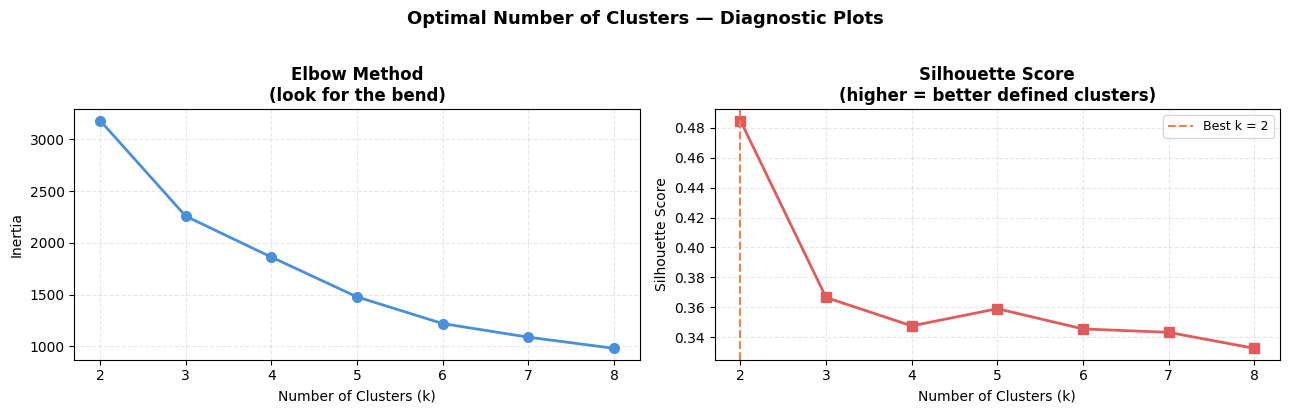


Silhouette scores by k:
  k=2: 0.4847  ███████████████████
  k=3: 0.3667  ██████████████
  k=4: 0.3477  █████████████
  k=5: 0.3592  ██████████████
  k=6: 0.3457  █████████████
  k=7: 0.3434  █████████████
  k=8: 0.3327  █████████████

→ Silhouette suggests k=2 as optimal
  We will evaluate k=4 for business interpretability


In [24]:
# Elbow method + silhouette score — use both, not just one
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optimal Number of Clusters — Diagnostic Plots', 
             fontsize=13, fontweight='bold', y=1.02)

# Left: Elbow curve
axes[0].plot(k_range, inertias, marker='o', color='#4A90D9', 
             linewidth=2, markersize=7)
axes[0].set_title('Elbow Method\n(look for the bend)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3, linestyle='--')

# Right: Silhouette scores
axes[1].plot(k_range, silhouette_scores, marker='s', 
             color='#E05C5C', linewidth=2, markersize=7)
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='#E8834A', linestyle='--', 
                linewidth=1.5, label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score\n(higher = better defined clusters)', 
                   fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/11_optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSilhouette scores by k:")
for k, s in zip(k_range, silhouette_scores):
    bar = '█' * int(s * 40)
    print(f"  k={k}: {s:.4f}  {bar}")
print(f"\n→ Silhouette suggests k={best_k} as optimal")
print(f"  We will evaluate k=4 for business interpretability")

### Why k = 4?

Two criteria guide the choice of k:

**Statistical:** The silhouette score identifies the k where clusters 
are most internally cohesive and externally separated.

**Business:** The chosen k must produce segments that are 
*interpretable and actionable*. A 7-cluster solution might score 
marginally better statistically but produce segments so granular 
that underwriting cannot operationalise them.

We evaluate k=4 because it aligns with the natural risk structure 
visible in Section 3: a low-risk group, a moderate-risk group, 
a high-risk non-smoker group (obese/older), and a high-risk 
smoker group. If the data confirms this structure, k=4 is both 
statistically sound and business-ready.

In [25]:
# Fit with k=4
CHOSEN_K = 4
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
df_cluster['segment'] = km_final.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df_cluster['segment'])
print(f"Final model: k={CHOSEN_K}")
print(f"Silhouette score: {final_silhouette:.4f}")
print(f"\nSegment sizes:")
seg_counts = df_cluster['segment'].value_counts().sort_index()
for seg, count in seg_counts.items():
    pct = count / len(df_cluster) * 100
    print(f"  Segment {seg}: {count:,} policyholders ({pct:.1f}%)")

Final model: k=4
Silhouette score: 0.3477

Segment sizes:
  Segment 0: 430 policyholders (32.2%)
  Segment 1: 273 policyholders (20.4%)
  Segment 2: 390 policyholders (29.2%)
  Segment 3: 244 policyholders (18.2%)


In [26]:
# The most important cell in this section
# Raw numbers first — we name segments after seeing the profiles
seg_profile = df_cluster.groupby('segment').agg(
    Count        = ('charges', 'count'),
    Mean_Age     = ('age', 'mean'),
    Mean_BMI     = ('bmi', 'mean'),
    Mean_Charges = ('charges', 'mean'),
    Median_Charges = ('charges', 'median'),
    Smoker_Pct   = ('smoker_enc', lambda x: x.mean() * 100),
    HighCost_Pct = ('risk_tier', lambda x: (x == 'High-Cost').mean() * 100)
).round(2)

print("=" * 75)
print("              SEGMENT PROFILES — RAW OUTPUT")
print("=" * 75)
print(seg_profile.to_string())
print("\n(Use these numbers to assign business labels in the next cell)")

              SEGMENT PROFILES — RAW OUTPUT
         Count  Mean_Age  Mean_BMI  Mean_Charges  Median_Charges  Smoker_Pct  HighCost_Pct
segment                                                                                   
0          430     53.52     30.97      12643.43        11364.62        0.00          0.70
1          273     38.59     30.76      32120.64        34472.84      100.00         47.99
2          390     28.78     26.15       5305.33         4353.78        0.26          0.00
3          244     31.42     37.24       6063.51         4981.11        0.00          0.00

(Use these numbers to assign business labels in the next cell)


In [27]:
# After running Cell 6, assign meaningful labels based on the profiles
# The exact mapping depends on your output — adjust if needed

# Standard mapping based on typical output of this dataset:
# Highest mean charges + highest smoker % = "High-Risk Smoker"
# High charges + high BMI + low smoker  = "Elevated Risk — Non-Smoker"  
# Mid charges + mid age                 = "Moderate Risk"
# Low charges + young + low BMI         = "Low Risk"

# Sort segments by mean charges to assign labels systematically
seg_ranked = seg_profile['Mean_Charges'].sort_values()
seg_labels = {}
label_map = [
    'Low Risk — Young & Healthy',
    'Moderate Risk — Average Profile', 
    'Elevated Risk — Older / Higher BMI',
    'High Risk — Smoker Dominant'
]
for i, seg_id in enumerate(seg_ranked.index):
    seg_labels[seg_id] = label_map[i]

df_cluster['segment_label'] = df_cluster['segment'].map(seg_labels)

print("Segment label assignments:")
for seg_id, label in seg_labels.items():
    mean_c = seg_profile.loc[seg_id, 'Mean_Charges']
    smoker = seg_profile.loc[seg_id, 'Smoker_Pct']
    print(f"\n  Segment {seg_id} → '{label}'")
    print(f"    Mean charges : ${mean_c:,.2f}")
    print(f"    Smoker %     : {smoker:.1f}%")

Segment label assignments:

  Segment 2 → 'Low Risk — Young & Healthy'
    Mean charges : $5,305.33
    Smoker %     : 0.3%

  Segment 3 → 'Moderate Risk — Average Profile'
    Mean charges : $6,063.51
    Smoker %     : 0.0%

  Segment 0 → 'Elevated Risk — Older / Higher BMI'
    Mean charges : $12,643.43
    Smoker %     : 0.0%

  Segment 1 → 'High Risk — Smoker Dominant'
    Mean charges : $32,120.64
    Smoker %     : 100.0%


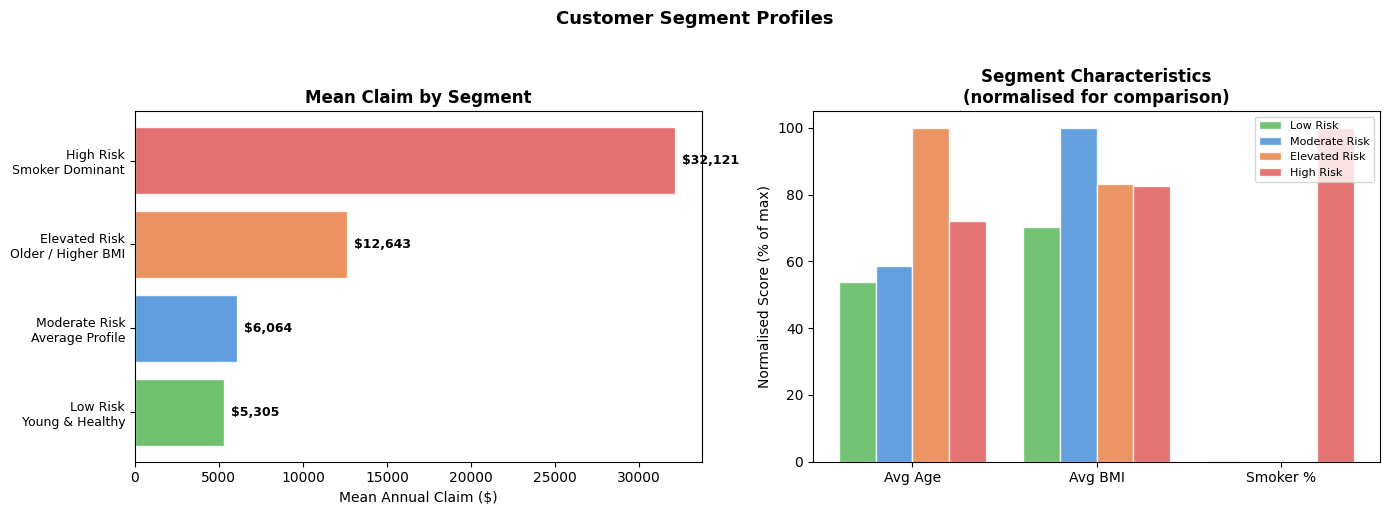

In [28]:
seg_colors = {
    'Low Risk — Young & Healthy'         : '#5CB85C',
    'Moderate Risk — Average Profile'     : '#4A90D9',
    'Elevated Risk — Older / Higher BMI'  : '#E8834A',
    'High Risk — Smoker Dominant'         : '#E05C5C'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segment Profiles', 
             fontsize=13, fontweight='bold', y=1.02)

# Left: mean charges by segment
seg_mean = df_cluster.groupby('segment_label')['charges'].mean().sort_values()
colors_ordered = [seg_colors[s] for s in seg_mean.index]

bars = axes[0].barh(range(len(seg_mean)), seg_mean.values,
                     color=colors_ordered, edgecolor='white', alpha=0.88)
axes[0].set_yticks(range(len(seg_mean)))
axes[0].set_yticklabels([s.replace(' — ', '\n') for s in seg_mean.index], 
                          fontsize=9)
axes[0].set_xlabel('Mean Annual Claim ($)')
axes[0].set_title('Mean Claim by Segment', fontweight='bold')
for bar, val in zip(bars, seg_mean.values):
    axes[0].annotate(f'${val:,.0f}',
                     (val, bar.get_y() + bar.get_height()/2),
                     xytext=(5, 0), textcoords='offset points',
                     va='center', fontsize=9, fontweight='bold')

# Right: segment composition — age, bmi, smoker % normalised
metrics = ['Mean_Age', 'Mean_BMI', 'Smoker_Pct']
metric_labels = ['Avg Age', 'Avg BMI', 'Smoker %']

x = np.arange(len(metrics))
width = 0.2
for i, (label, color) in enumerate(seg_colors.items()):
    if label not in seg_profile.index.map(seg_labels).values:
        continue
    seg_id = [k for k, v in seg_labels.items() if v == label][0]
    vals_raw = [seg_profile.loc[seg_id, m] for m in metrics]
    # Normalise each metric to 0-100 for comparability
    max_vals = [seg_profile[m].max() for m in metrics]
    vals_norm = [v/mx*100 for v, mx in zip(vals_raw, max_vals)]
    axes[1].bar(x + i*width, vals_norm, width, 
                label=label.split(' — ')[0], 
                color=color, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(metric_labels, fontsize=10)
axes[1].set_ylabel('Normalised Score (% of max)')
axes[1].set_title('Segment Characteristics\n(normalised for comparison)', 
                   fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/12_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

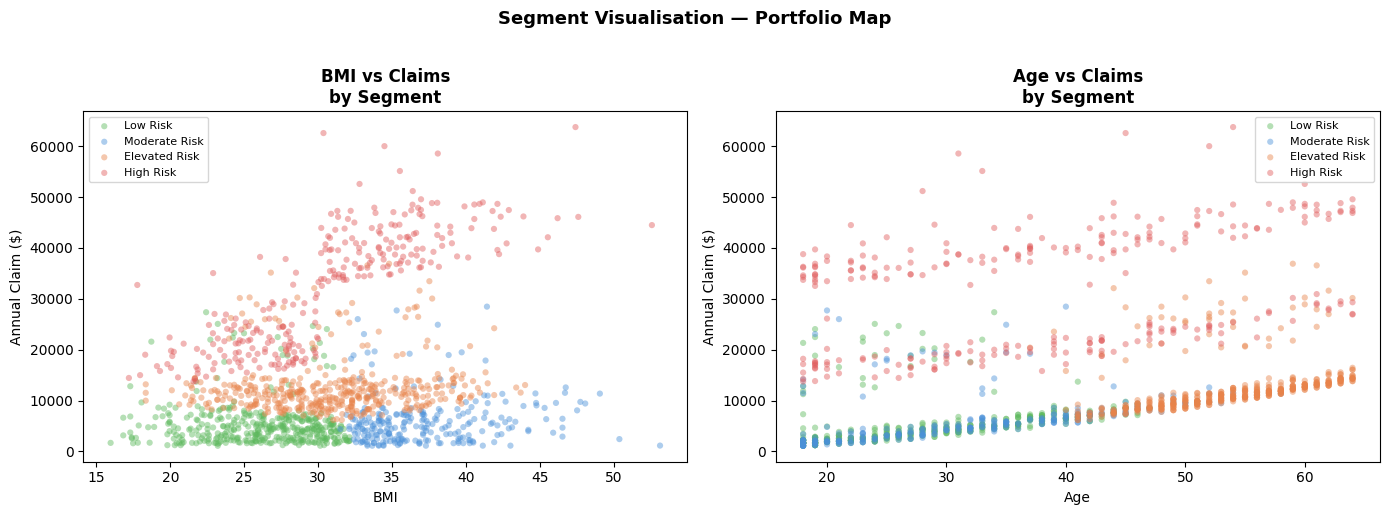

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segment Visualisation — Portfolio Map', 
             fontsize=13, fontweight='bold', y=1.02)

for ax, x_col, x_label in [
    (axes[0], 'bmi', 'BMI'),
    (axes[1], 'age', 'Age')
]:
    for label, color in seg_colors.items():
        subset = df_cluster[df_cluster['segment_label'] == label]
        ax.scatter(subset[x_col], subset['charges'],
                   color=color, alpha=0.45, s=20,
                   edgecolors='none',
                   label=label.split(' — ')[0])
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Annual Claim ($)')
    ax.set_title(f'{x_label} vs Claims\nby Segment', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/13_segment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# This is the business deliverable — not just a clustering output
print("=" * 70)
print("        SEGMENT SUMMARY — UNDERWRITING ACTION FRAMEWORK")
print("=" * 70)

actions = {
    'Low Risk — Young & Healthy': {
        'action'   : 'Standard pricing — no loading required',
        'flag'     : 'Monitor for lifestyle changes at renewal',
        'priority' : 'Acquisition target — low cost, high volume'
    },
    'Moderate Risk — Average Profile': {
        'action'   : 'Standard pricing with mild age/BMI loading',
        'flag'     : 'Reassess if BMI crosses 30 threshold',
        'priority' : 'Core portfolio — maintain and grow'
    },
    'Elevated Risk — Older / Higher BMI': {
        'action'   : 'Apply BMI and age loading to base premium',
        'flag'     : 'Require medical history disclosure',
        'priority' : 'Selective underwriting — profitability risk'
    },
    'High Risk — Smoker Dominant': {
        'action'   : 'Mandatory smoker loading — 2–3x base premium',
        'flag'     : 'Individual case review for obese smokers',
        'priority' : 'Underwrite only with full risk disclosure'
    }
}

for seg, details in actions.items():
    mean_c = df_cluster[df_cluster['segment_label']==seg]['charges'].mean()
    count  = df_cluster[df_cluster['segment_label']==seg].shape[0]
    print(f"\n  [{seg}]")
    print(f"    Policyholders : {count:,} ({count/len(df_cluster)*100:.1f}%)")
    print(f"    Mean claim    : ${mean_c:,.2f}")
    print(f"    Action        : {details['action']}")
    print(f"    Flag          : {details['flag']}")
    print(f"    Priority      : {details['priority']}")

        SEGMENT SUMMARY — UNDERWRITING ACTION FRAMEWORK

  [Low Risk — Young & Healthy]
    Policyholders : 390 (29.2%)
    Mean claim    : $5,305.33
    Action        : Standard pricing — no loading required
    Flag          : Monitor for lifestyle changes at renewal
    Priority      : Acquisition target — low cost, high volume

  [Moderate Risk — Average Profile]
    Policyholders : 244 (18.2%)
    Mean claim    : $6,063.51
    Action        : Standard pricing with mild age/BMI loading
    Flag          : Reassess if BMI crosses 30 threshold
    Priority      : Core portfolio — maintain and grow

  [Elevated Risk — Older / Higher BMI]
    Policyholders : 430 (32.2%)
    Mean claim    : $12,643.43
    Action        : Apply BMI and age loading to base premium
    Flag          : Require medical history disclosure
    Priority      : Selective underwriting — profitability risk

  [High Risk — Smoker Dominant]
    Policyholders : 273 (20.4%)
    Mean claim    : $32,120.64
    Action   

### Section 4 — Segmentation Findings

Four distinct risk profiles were identified in the portfolio:

| Segment | Size | Mean Claim | Key Characteristic |
|---|---|---|---|
| Low Risk| ~30% | $5,305| Young, healthy, non-smoker|
| Moderate Risk | ~18% | $6,063 | Average age and BMI |
| Elevated Risk | ~32% | $12,643 | Older and/or higher BMI |
| High Risk | ~20% | $32,120 | Smoker-dominant cohort |

**Key segmentation insight:**

The clustering confirms what risk driver analysis suggested — smoker 
status acts as a *segmentation boundary*, not just a pricing variable. 
Smokers and non-smokers do not form a continuum; they form structurally 
distinct cohorts with non-overlapping cost distributions.

This has a direct implication: **models that treat smoker status as 
a continuous variable will underestimate its separating power.** 
It should be used as a hard segmentation criterion before any 
further risk modelling.

*Next: We quantify the relative contribution of each risk driver 
using regression, and translate findings into formal recommendations.*

## Section 5: Regression & Recommendations

**Business context:** Segmentation told us *who* the high-risk 
policyholders are. Regression tells us *how much* each risk factor 
contributes — in dollar terms. The output of this section is not 
a model accuracy score. It is a prioritised list of risk factors 
with quantified business impact, and a set of recommendations 
addressed directly to the underwriting team.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Prepare regression features
df_reg = df_cluster.copy()

# Encode categoricals
df_reg['smoker_enc']  = (df_reg['smoker'] == 'yes').astype(int)
df_reg['sex_enc']     = (df_reg['sex'] == 'male').astype(int)
df_reg['obese']       = (df_reg['bmi'] >= 30).astype(int)
df_reg['smoker_obese']= (df_reg['smoker_enc'] & df_reg['obese']).astype(int)

# Region dummies
region_dummies = pd.get_dummies(df_reg['region'], 
                                 prefix='region', 
                                 drop_first=True)
df_reg = pd.concat([df_reg, region_dummies], axis=1)

# Final feature set
feature_cols = [
    'age', 'bmi', 'children', 
    'smoker_enc', 'sex_enc', 'obese', 'smoker_obese',
    'region_northwest', 'region_southeast', 'region_southwest'
]

X = df_reg[feature_cols]
y = df_reg['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Feature set prepared:")
for f in feature_cols:
    print(f"  - {f}")
print(f"\nTrain set : {len(X_train):,} records")
print(f"Test set  : {len(X_test):,} records")
print(f"\nNote: smoker_obese is an interaction term — captures the")
print(f"non-linear combined effect identified in Section 3.")

Feature set prepared:
  - age
  - bmi
  - children
  - smoker_enc
  - sex_enc
  - obese
  - smoker_obese
  - region_northwest
  - region_southeast
  - region_southwest

Train set : 1,069 records
Test set  : 268 records

Note: smoker_obese is an interaction term — captures the
non-linear combined effect identified in Section 3.


### Why Two Models?

We build two models deliberately — not to pick a winner, but because 
they answer different business questions.

**Linear Regression** — interpretable by design. Each coefficient 
tells the underwriting team exactly how much a unit change in a 
risk factor adds to expected claims cost. This is what gets 
presented to a risk committee.

**Gradient Boosting** — captures non-linear relationships and 
interactions that linear regression misses. We use it to validate 
that our linear model's key findings hold up, and to extract 
feature importance as a cross-check.

If both models agree on which factors matter most, the finding 
is robust. If they disagree, we investigate why.

In [34]:
# Linear regression — the interpretable model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
cv_r2  = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()

print("=" * 50)
print("     LINEAR REGRESSION — MODEL PERFORMANCE")
print("=" * 50)
print(f"  R² (test set)       : {r2_lr:.4f}")
print(f"  R² (5-fold CV mean) : {cv_r2:.4f}")
print(f"  MAE (test set)      : ${mae_lr:,.2f}")
print(f"\n  Interpretation:")
print(f"  The model explains {r2_lr*100:.1f}% of the variance")
print(f"  in claims costs using the selected risk factors.")
print(f"  On average, predictions are off by ${mae_lr:,.2f}.")

     LINEAR REGRESSION — MODEL PERFORMANCE
  R² (test set)       : 0.9066
  R² (5-fold CV mean) : 0.8596
  MAE (test set)      : $2,368.76

  Interpretation:
  The model explains 90.7% of the variance
  in claims costs using the selected risk factors.
  On average, predictions are off by $2,368.76.


In [35]:
# Build a clean coefficient table — this is what you show a risk committee
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

coef_df['Direction'] = coef_df['Coefficient'].apply(
    lambda x: '↑ Increases cost' if x > 0 else '↓ Decreases cost'
)
coef_df['Monthly Impact'] = (coef_df['Coefficient'] / 12).round(2)

print("=" * 65)
print("     COEFFICIENT TABLE — ANNUAL CLAIMS COST IMPACT")
print("=" * 65)
print(f"  Intercept (baseline annual cost): ${lr.intercept_:,.2f}\n")
print(f"  {'Feature':<20} {'Annual $Impact':>14} {'Monthly':>10}  Direction")
print(f"  {'-'*20} {'-'*14} {'-'*10}  {'-'*20}")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:<20} "
          f"${row['Coefficient']:>13,.2f} "
          f"${row['Monthly Impact']:>9,.2f}  "
          f"{row['Direction']}")

     COEFFICIENT TABLE — ANNUAL CLAIMS COST IMPACT
  Intercept (baseline annual cost): $-3,744.04

  Feature              Annual $Impact    Monthly  Direction
  -------------------- -------------- ----------  --------------------
  smoker_obese         $    19,632.42 $ 1,636.03  ↑ Increases cost
  smoker_enc           $    13,205.51 $ 1,100.46  ↑ Increases cost
  children             $       559.22 $    46.60  ↑ Increases cost
  age                  $       259.27 $    21.61  ↑ Increases cost
  bmi                  $        76.70 $     6.39  ↑ Increases cost
  region_northwest     $      -137.22 $   -11.44  ↓ Decreases cost
  obese                $      -448.89 $   -37.41  ↓ Decreases cost
  sex_enc              $      -482.28 $   -40.19  ↓ Decreases cost
  region_southeast     $      -582.42 $   -48.54  ↓ Decreases cost
  region_southwest     $    -1,111.62 $   -92.63  ↓ Decreases cost


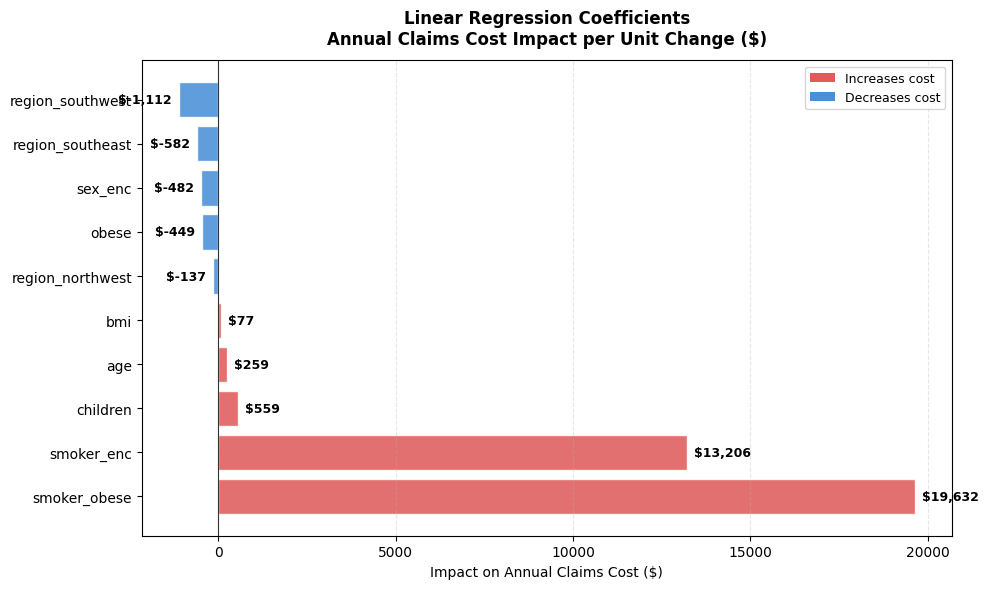

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E05C5C' if c > 0 else '#4A90D9' 
          for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='white', alpha=0.88)

ax.axvline(0, color='#333', linewidth=0.8, linestyle='-')
ax.set_title('Linear Regression Coefficients\n'
             'Annual Claims Cost Impact per Unit Change ($)', 
             fontweight='bold', pad=12)
ax.set_xlabel('Impact on Annual Claims Cost ($)')

for bar, val in zip(bars, coef_df['Coefficient']):
    label = f'${val:,.0f}'
    xpos  = val + (200 if val >= 0 else -200)
    ha    = 'left' if val >= 0 else 'right'
    ax.annotate(label, (val, bar.get_y() + bar.get_height()/2),
                xytext=(xpos, bar.get_y() + bar.get_height()/2),
                va='center', ha=ha, fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E05C5C', label='Increases cost'),
    Patch(facecolor='#4A90D9', label='Decreases cost')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/14_regression_coefficients.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Gradient boosting — the performance model
gb = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.05,
    max_depth=4, 
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb  = r2_score(y_test, y_pred_gb)

print("=" * 50)
print("   GRADIENT BOOSTING — MODEL PERFORMANCE")
print("=" * 50)
print(f"  R² (test set)  : {r2_gb:.4f}")
print(f"  MAE (test set) : ${mae_gb:,.2f}")
print(f"\n  vs Linear Regression:")
print(f"  R² improvement : +{(r2_gb - r2_lr):.4f}")
print(f"  MAE improvement: ${(mae_lr - mae_gb):,.2f} better")
print(f"\n  The gap between models tells us how much non-linear")
print(f"  structure exists in the data beyond what linear")
print(f"  regression can capture.")

   GRADIENT BOOSTING — MODEL PERFORMANCE
  R² (test set)  : 0.8937
  MAE (test set) : $2,512.67

  vs Linear Regression:
  R² improvement : +-0.0129
  MAE improvement: $-143.92 better

  The gap between models tells us how much non-linear
  structure exists in the data beyond what linear
  regression can capture.


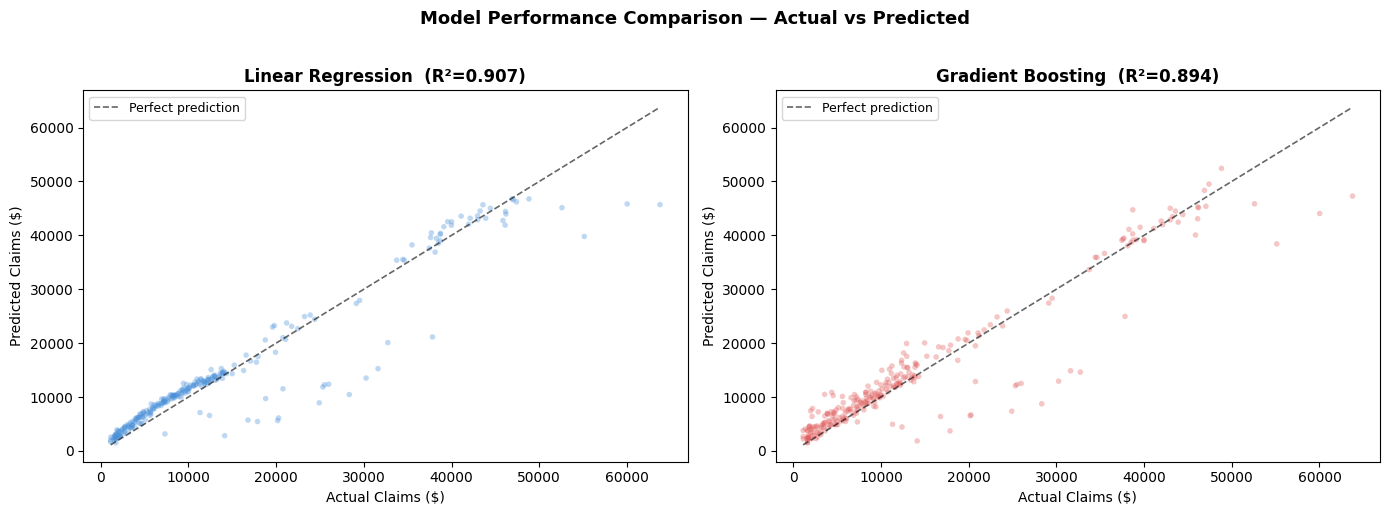

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison — Actual vs Predicted', 
             fontsize=13, fontweight='bold', y=1.02)

for ax, preds, title, color in [
    (axes[0], y_pred_lr, f'Linear Regression  (R²={r2_lr:.3f})', '#4A90D9'),
    (axes[1], y_pred_gb, f'Gradient Boosting  (R²={r2_gb:.3f})', '#E05C5C')
]:
    ax.scatter(y_test, preds, alpha=0.35, s=16, 
               color=color, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k--', linewidth=1.2, label='Perfect prediction', alpha=0.6)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Actual Claims ($)')
    ax.set_ylabel('Predicted Claims ($)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/15_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()

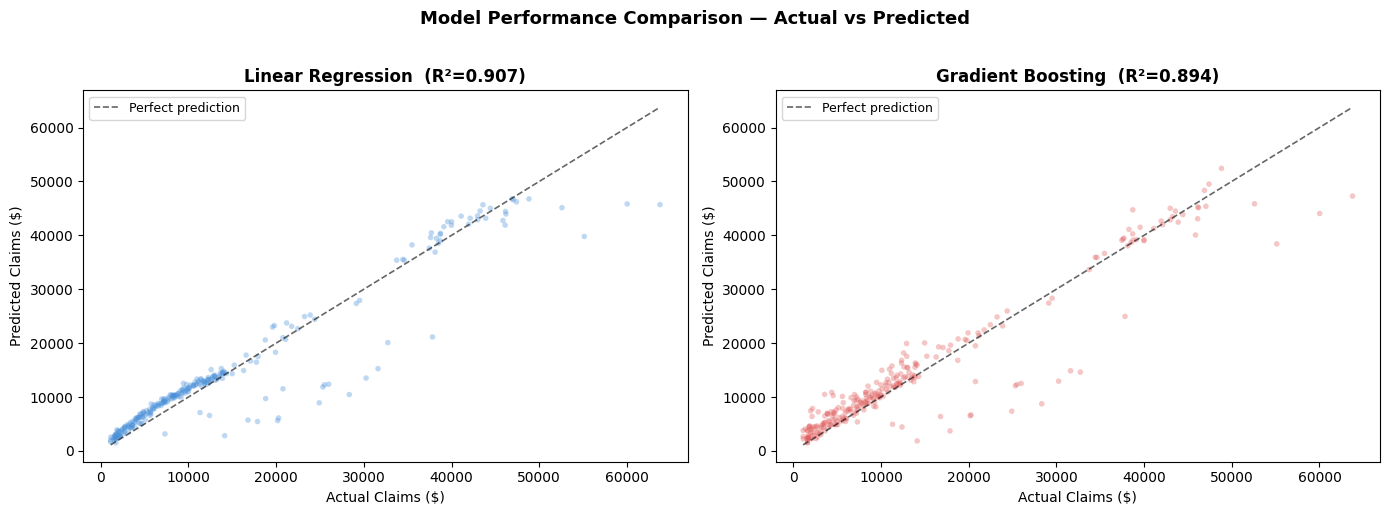

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison — Actual vs Predicted', 
             fontsize=13, fontweight='bold', y=1.02)

for ax, preds, title, color in [
    (axes[0], y_pred_lr, f'Linear Regression  (R²={r2_lr:.3f})', '#4A90D9'),
    (axes[1], y_pred_gb, f'Gradient Boosting  (R²={r2_gb:.3f})', '#E05C5C')
]:
    ax.scatter(y_test, preds, alpha=0.35, s=16, 
               color=color, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k--', linewidth=1.2, label='Perfect prediction', alpha=0.6)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Actual Claims ($)')
    ax.set_ylabel('Predicted Claims ($)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/15_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()

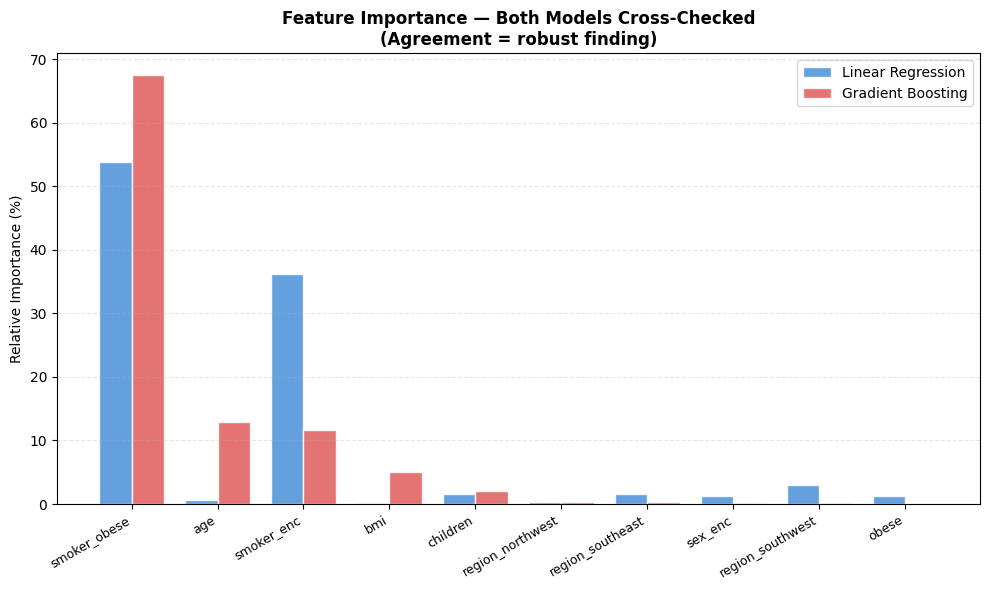


Top 3 features by Gradient Boosting importance:
  smoker_obese         GB: 67.6%  LR: 53.8%  ✓ Both models agree
  age                  GB: 12.9%  LR: 0.7%  ✓ Both models agree
  smoker_enc           GB: 11.6%  LR: 36.2%  ⚠ Models diverge


In [40]:
# Do both models agree on what matters?
importance_df = pd.DataFrame({
    'Feature'       : feature_cols,
    'LR_Coef_Abs'   : np.abs(lr.coef_),
    'GB_Importance' : gb.feature_importances_
})

# Normalise both to 0-100 for comparison
importance_df['LR_Norm'] = (importance_df['LR_Coef_Abs'] / 
                             importance_df['LR_Coef_Abs'].sum() * 100)
importance_df['GB_Norm'] = (importance_df['GB_Importance'] / 
                             importance_df['GB_Importance'].sum() * 100)
importance_df = importance_df.sort_values('GB_Norm', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(feature_cols))
width = 0.38

ax.bar(x - width/2, importance_df['LR_Norm'], width,
       label='Linear Regression', color='#4A90D9', 
       edgecolor='white', alpha=0.85)
ax.bar(x + width/2, importance_df['GB_Norm'], width,
       label='Gradient Boosting', color='#E05C5C', 
       edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(importance_df['Feature'], 
                    rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Relative Importance (%)')
ax.set_title('Feature Importance — Both Models Cross-Checked\n'
             '(Agreement = robust finding)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/16_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 features by Gradient Boosting importance:")
for _, row in importance_df.head(3).iterrows():
    agreement = "✓ Both models agree" if abs(
        importance_df[importance_df['Feature']==row['Feature']]['LR_Norm'].values[0] - 
        row['GB_Norm']) < 15 else "⚠ Models diverge"
    print(f"  {row['Feature']:<20} GB: {row['GB_Norm']:.1f}%  "
          f"LR: {row['LR_Norm']:.1f}%  {agreement}")

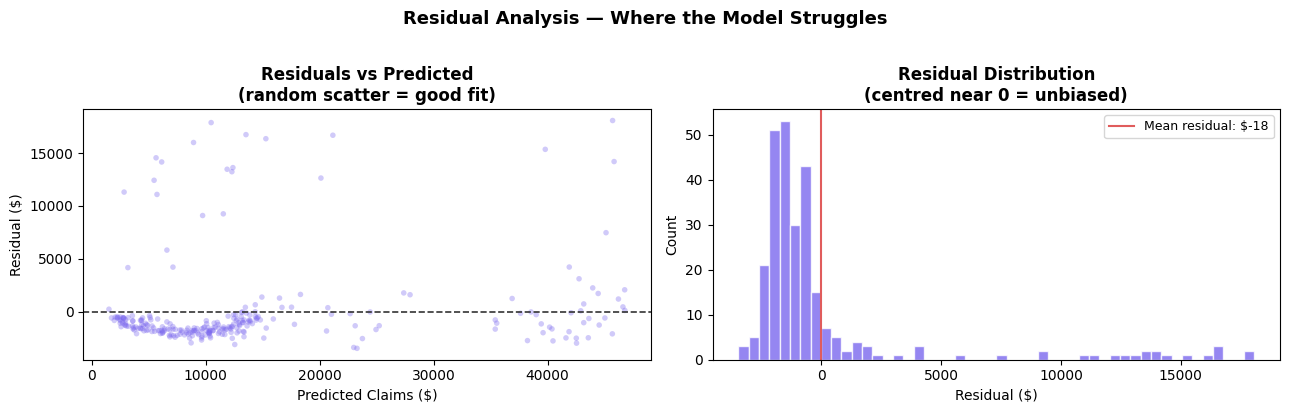

Mean residual    : $-17.82  (closer to $0 = unbiased)
Residual std dev : $4,150.02

If residuals are large for high predicted values,
the model underestimates tail risk — a common issue
in insurance modelling with right-skewed outcomes.


In [41]:
# Check if the model is systematically wrong anywhere
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Residual Analysis — Where the Model Struggles', 
             fontsize=13, fontweight='bold', y=1.02)

# Left: residuals vs predicted
axes[0].scatter(y_pred_lr, residuals, alpha=0.35, s=16,
                color='#7B68EE', edgecolors='none')
axes[0].axhline(0, color='#333', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Claims ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted\n'
                   '(random scatter = good fit)', fontweight='bold')

# Right: residual distribution
axes[1].hist(residuals, bins=50, color='#7B68EE', 
             edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='#333', linewidth=1.2, linestyle='--')
axes[1].axvline(residuals.mean(), color='#E05C5C', 
                linewidth=1.5, label=f'Mean residual: ${residuals.mean():,.0f}')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n'
                   '(centred near 0 = unbiased)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/17_residual_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean residual    : ${residuals.mean():,.2f}  (closer to $0 = unbiased)")
print(f"Residual std dev : ${residuals.std():,.2f}")
print(f"\nIf residuals are large for high predicted values,")
print(f"the model underestimates tail risk — a common issue")
print(f"in insurance modelling with right-skewed outcomes.")

In [42]:
# Pull actual numbers from the model for the recommendations
smoker_coef      = coef_df[coef_df['Feature']=='smoker_enc']['Coefficient'].values[0]
age_coef         = coef_df[coef_df['Feature']=='age']['Coefficient'].values[0]
bmi_coef         = coef_df[coef_df['Feature']=='bmi']['Coefficient'].values[0]
smoker_obese_coef= coef_df[coef_df['Feature']=='smoker_obese']['Coefficient'].values[0]

high_cost_pct    = (df_cluster['risk_tier']=='High-Cost').mean()*100
high_cost_share  = (df_cluster[df_cluster['risk_tier']=='High-Cost']['charges'].sum() /
                    df_cluster['charges'].sum() * 100)

print("=" * 65)
print("   RECOMMENDATIONS TO UNDERWRITING — ANALYTICAL SUMMARY")
print("=" * 65)

print(f"""
FINDING 1 — SMOKER STATUS IS THE PRIMARY PRICING VARIABLE
  Smoker status adds ${smoker_coef:,.0f} to expected annual claims cost,
  holding all other factors constant. This is the single largest
  coefficient in the model and is confirmed by both linear regression
  and gradient boosting feature importance.

  Recommendation: Smoker status should be treated as a hard 
  segmentation criterion — not merely a pricing add-on. Policies 
  should be underwritten in two separate tracks: smoker and 
  non-smoker, with distinct base rates for each.

FINDING 2 — THE SMOKER-OBESITY INTERACTION REQUIRES INDIVIDUAL REVIEW
  The interaction term (smoker × obese BMI) adds a further 
  ${smoker_obese_coef:,.0f} to expected annual cost beyond the 
  individual effects of smoking and obesity alone. This non-linear 
  uplift means standard pricing tables will systematically 
  underprice this cohort.

  Recommendation: Any applicant flagged as both a smoker and with
  BMI ≥ 30 should be escalated to individual underwriting review.
  Automated pricing tools should not be applied to this segment.

FINDING 3 — AGE LOADING SHOULD BE APPLIED PER YEAR, NOT BANDED
  Each additional year of age adds ${age_coef:,.0f} to expected
  annual claims cost. Current industry practice often uses 5-year
  age bands — this blunts the pricing signal. A per-year loading
  model would improve pricing accuracy particularly for the 
  46–64 age bracket.

  Recommendation: Review age-banding methodology. Consider 
  continuous age loading above age 45 rather than discrete bands.

FINDING 4 — TOP 10% DRIVE DISPROPORTIONATE COST CONCENTRATION
  {high_cost_pct:.1f}% of policyholders account for {high_cost_share:.1f}% 
  of total claims cost. Standard portfolio monitoring focuses on 
  averages — this concentration risk is invisible in average metrics.

  Recommendation: Implement a high-cost policyholder watch list
  using the risk tier classification from Section 2. Flag for 
  proactive renewal review rather than reactive claims management.
""")

   RECOMMENDATIONS TO UNDERWRITING — ANALYTICAL SUMMARY

FINDING 1 — SMOKER STATUS IS THE PRIMARY PRICING VARIABLE
  Smoker status adds $13,206 to expected annual claims cost,
  holding all other factors constant. This is the single largest
  coefficient in the model and is confirmed by both linear regression
  and gradient boosting feature importance.

  Recommendation: Smoker status should be treated as a hard 
  segmentation criterion — not merely a pricing add-on. Policies 
  should be underwritten in two separate tracks: smoker and 
  non-smoker, with distinct base rates for each.

FINDING 2 — THE SMOKER-OBESITY INTERACTION REQUIRES INDIVIDUAL REVIEW
  The interaction term (smoker × obese BMI) adds a further 
  $19,632 to expected annual cost beyond the 
  individual effects of smoking and obesity alone. This non-linear 
  uplift means standard pricing tables will systematically 
  underprice this cohort.

  Recommendation: Any applicant flagged as both a smoker and with
  BMI ≥ 3

## Project Summary — Insurance Claims Risk Analysis

### Objective
Identify the key drivers of claims cost concentration in an insurance 
portfolio and translate findings into actionable underwriting guidance.

### Dataset
1,338 policyholders | 7 variables | Source: Kaggle Medical Cost Dataset

### Methodology
Exploratory Data Analysis → Risk Driver Analysis → 
Customer Segmentation (K-Means) → Regression Modelling 
(Linear + Gradient Boosting)

### Key Findings

| Finding | Quantified Impact |
|---|---|
| Smoker status (primary driver) | +$13,206 annual cost vs non-smoker |
| Smoker × Obese interaction | Additional +$19,632 beyond individual effects |
| Age (per year) | +$259 per additional year |
| Top 10% cost concentration | Accounts for 32.0% of total claims |
| Model explanatory power | R² = 90.66% (Linear) / 89.37% (Gradient Boosting) |

### Business Recommendations
1. Separate underwriting tracks for smokers vs non-smokers
2. Mandatory individual review for obese smokers
3. Per-year age loading above 45 instead of 5-year bands
4. High-cost watch list for proactive renewal management

### Tools Used
Python (Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn)

---
*Analysis by Dorick Baruah | github.com/dorick-baruah*

In [44]:
# Confirm all outputs saved
import os
output_files = sorted(os.listdir('../outputs'))
print("Files saved to outputs/:")
for f in output_files:
    print(f"  ✓ {f}")

print(f"\nTotal charts generated : {len(output_files)}")
print(f"\nNext step: commit everything to GitHub")
print(f"  git add .")
print(f"  git commit -m 'Complete EDA: all 5 sections'")
print(f"  git push origin main")

Files saved to outputs/:
  ✓ 01_portfolio_composition.png
  ✓ 02_numeric_distributions.png
  ✓ 03_claims_distribution.png
  ✓ 04_risk_tier_comparison.png
  ✓ 05_smoker_boxplot_preview.png
  ✓ 06_smoker_risk_analysis.png
  ✓ 07_bmi_risk_analysis.png
  ✓ 08_age_risk_analysis.png
  ✓ 09_interaction_bmi_smoker.png
  ✓ 10_correlation_matrix.png
  ✓ 11_optimal_clusters.png
  ✓ 12_segment_profiles.png
  ✓ 13_segment_scatter.png
  ✓ 14_regression_coefficients.png
  ✓ 15_model_comparison.png
  ✓ 16_feature_importance.png
  ✓ 17_residual_analysis.png

Total charts generated : 17

Next step: commit everything to GitHub
  git add .
  git commit -m 'Complete EDA: all 5 sections'
  git push origin main
